[HybridVideoMAE](https://github.com/OpenGVLab/VideoMAEv2/blob/master/dataset/pretrain_datasets.py#L268)

In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [2]:
from pathlib import Path

from functools import partial

import torch
import numpy as np
from PIL import Image
from torch.utils.data._utils.collate import default_collate

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.parameter_parser import parser
from computer_vision.video_mae.dataset.pretrained_datasets import HybridVideoMAE, DataAugmentationForVideoMAEv2
from computer_vision.video_mae.models.modeling_pretrain import pretrain_videomae_tiny_patch16_224
from computer_vision.video_mae.utils import seed_worker

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'
metadata_path=data_dirpath/'metadata_framerate4.pt'

mini_train=False
if not mini_train:
    output_dirpath=Path('D:/results/ucf101/video_mae/train') 
    arguments= f"""--data_root {root} --data_path {annotation_path}  --num_sample 4
    """ # --use-cutmix-mixup
else:
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_train') 
    arguments= f"""--data_root {root} --data_path {annotation_path}  --num_sample 4
    """ # --use-cutmix-mixup --time 18
args=parser.parse_args(arguments.split())
args.num_frames, args.sampling_rate, args.mask_type, args.decoder_mask_ratio, args.decoder_mask_type, args.model

(16, 4, 'tube', 0.5, 'run_cell', 'pretrain_videomae_tiny_patch16_224')

In [4]:
model = pretrain_videomae_tiny_patch16_224(args) 
print(f'{model.encoder.patch_embed.patch_size=}, {args.tubelet_size=}')
patch_size=model.encoder.patch_embed.patch_size
args.window_size=(args.num_frames//args.tubelet_size,
                  args.input_size//patch_size[0],
                  args.input_size//patch_size[1])
args.patch_size=patch_size
print(f'{args.window_size=}, {args.mask_ratio=}')

model.encoder.patch_embed.patch_size=(16, 16), args.tubelet_size=2
args.window_size=(8, 14, 14), args.mask_ratio=0.9


In [5]:
transform = DataAugmentationForVideoMAEv2(args)
dataset=HybridVideoMAE(root=args.data_root, setting=args.data_path, train=True, test_mode=False, name_pattern=args.fname_tmpl, 
                       video_ext='avi', is_color=True, modality='rgb', num_segments=1, num_crop=1, new_length=args.num_frames, 
                       new_step=args.sampling_rate, transform=transform, temporal_jitter=False, lazy_init=False, num_sample=args.num_sample)

In [6]:
index=890
process_data, encoder_mask, decoder_mask=dataset[index]
if isinstance(process_data, torch.Tensor):
    print(f"{type(process_data)=}, {process_data.shape=}, {process_data.dtype}, ({process_data.min().item():.3f},{process_data.max().item():.3f})")
    print(f"{type(encoder_mask)=}, {encoder_mask.shape=}, {encoder_mask.dtype}, ({encoder_mask.min().item():.3f},{encoder_mask.max().item():.3f})")
    print(f"{type(decoder_mask)=}, {decoder_mask.shape=}, {decoder_mask.dtype}, ({decoder_mask.min().item():.3f},{decoder_mask.max().item():.3f})")
else:
    print(f"{type(process_data)=}, {len(process_data)=}, {[x.shape for x in process_data]=}, {[type(x) for x in process_data]=}")
    print(f"{type(encoder_mask)=}, {len(encoder_mask)=}, {[x.shape for x in encoder_mask]=}, {[type(x) for x in encoder_mask]=}")
    print(f"{type(decoder_mask)=}, {len(decoder_mask)=}, {[x.shape for x in decoder_mask]=}, {[type(x) for x in decoder_mask]=}")

type(process_data)=<class 'list'>, len(process_data)=4, [x.shape for x in process_data]=[torch.Size([3, 16, 224, 224]), torch.Size([3, 16, 224, 224]), torch.Size([3, 16, 224, 224]), torch.Size([3, 16, 224, 224])], [type(x) for x in process_data]=[<class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>]
type(encoder_mask)=<class 'list'>, len(encoder_mask)=4, [x.shape for x in encoder_mask]=[(8, 196), (8, 196), (8, 196), (8, 196)], [type(x) for x in encoder_mask]=[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]
type(decoder_mask)=<class 'list'>, len(decoder_mask)=4, [x.shape for x in decoder_mask]=[(8, 196), (8, 196), (8, 196), (8, 196)], [type(x) for x in decoder_mask]=[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


(np.float64(-0.5), np.float64(1357.5), np.float64(679.5), np.float64(-0.5))

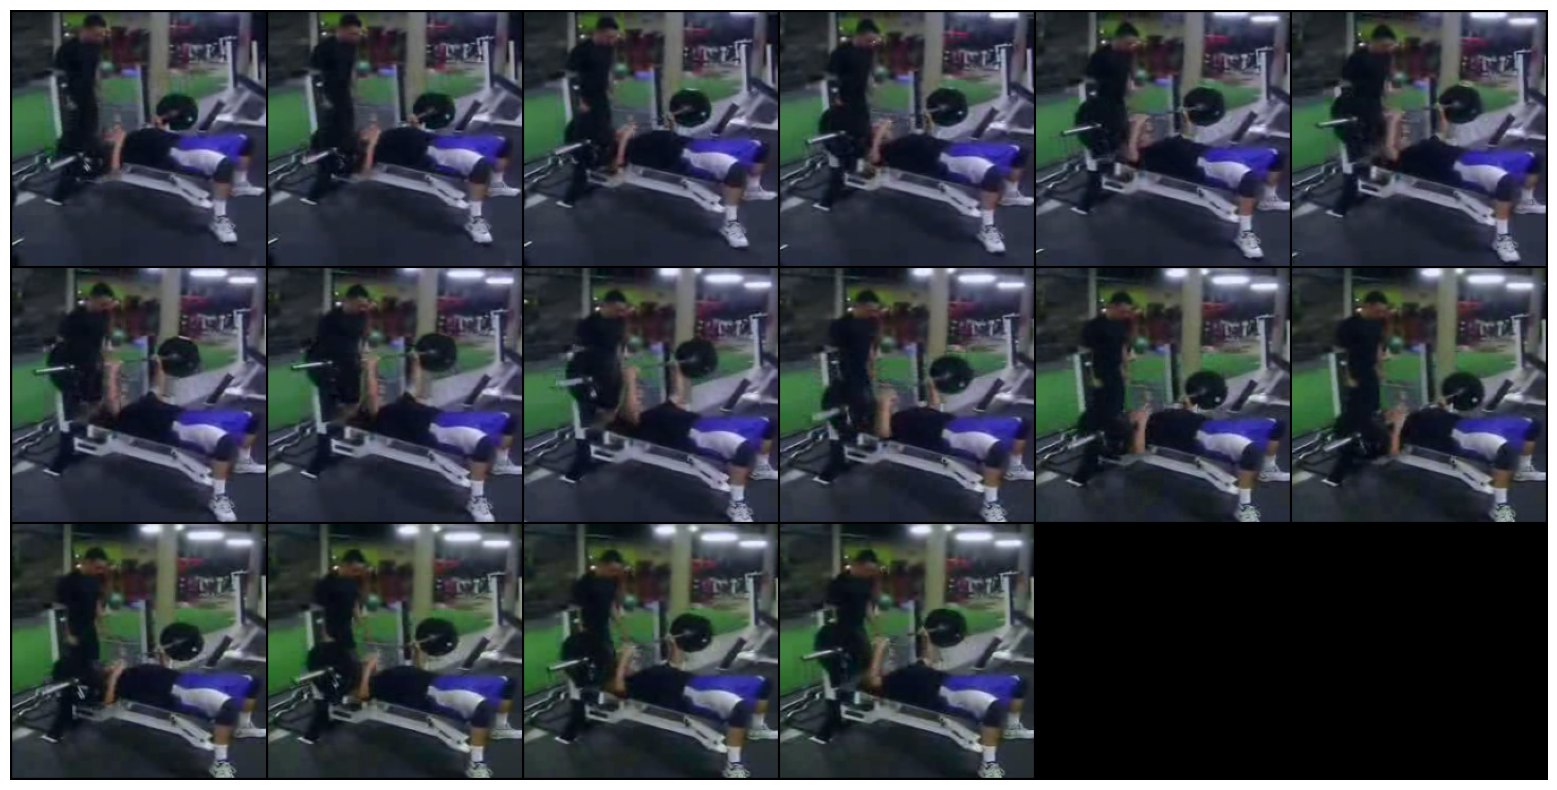

In [7]:
plt.figure(figsize=(20,10))
plt.imshow(make_grid(process_data[0].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

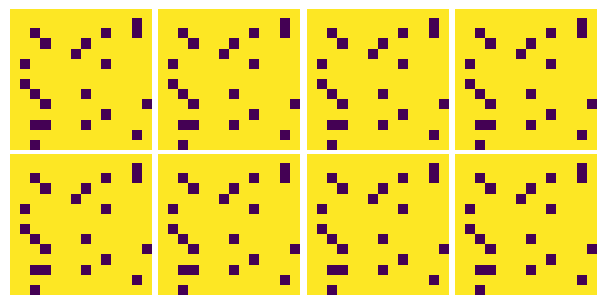

In [8]:
mask_tubes=encoder_mask[0].reshape(args.window_size)
fig, ax=plt.subplots(2,4,figsize=(6,3))
for i in range(2):
    for j in range(4):
        k=4*i+j
        ax[i,j].imshow(mask_tubes[k])#, cmap='gray')
        ax[i,j].axis('off')
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

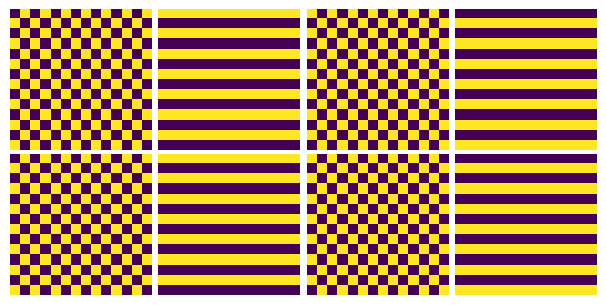

In [9]:
mask_tubes=decoder_mask[0].reshape(args.window_size)
fig, ax=plt.subplots(2,4,figsize=(6,3))
for i in range(2):
    for j in range(4):
        k=4*i+j
        ax[i,j].imshow(mask_tubes[k])#, cmap='gray')
        ax[i,j].axis('off')
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

In [11]:
def multiple_pretrain_samples_collate(batch, fold=False):
    """Collate function for repeated augmentation. Each instance in the batch has more than one sample
    Args:
        batch (tuple|list): Data batch to collate
    Returns:
        (tuple): Collated data batch
    """
    process_data, encoder_mask, decoder_mask=zip(*batch)
    process_data=[item for sublist in process_data for item in sublist]
    encoder_mask=[item for sublist in encoder_mask for item in sublist]
    decoder_mask=[item for sublist in decoder_mask for item in sublist]
    process_data, encoder_mask, decoder_mask=(default_collate(process_data), default_collate(encoder_mask), default_collate(decoder_mask))
    if fold: return [process_data], encoder_mask, decoder_mask
    return process_data, encoder_mask, decoder_mask

In [13]:
num_devices=torch.cuda.device_count() # number of CUDA devices
dataloader=torch.utils.data.DataLoader(dataset=dataset, batch_size=args.batch_size, shuffle=True, num_workers=0,#args.num_workers, 
                                       pin_memory=num_devices>0 and args.pin_mem, drop_last=len(dataset)%args.batch_size!=0, 
                                       worker_init_fn=seed_worker, persistent_workers=False, 
                                       collate_fn=partial(multiple_pretrain_samples_collate, fold=False))
data=next(iter(dataloader))
print(f"{type(data)=}, {len(data)=}")
video_data, encoder_mask, decoder_mask=data
print(f"video_data: {type(video_data)=}, {video_data.shape=}")
print(f"encoder_mask: {type(encoder_mask)=}, {encoder_mask.shape=}")
print(f"decoder_mask: {type(decoder_mask)=}, {decoder_mask.shape=}")

type(data)=<class 'tuple'>, len(data)=3
video_data: type(video_data)=<class 'torch.Tensor'>, video_data.shape=torch.Size([64, 3, 16, 224, 224])
encoder_mask: type(encoder_mask)=<class 'torch.Tensor'>, encoder_mask.shape=torch.Size([64, 8, 196])
decoder_mask: type(decoder_mask)=<class 'torch.Tensor'>, decoder_mask.shape=torch.Size([64, 8, 196])


(np.float64(-0.5), np.float64(1357.5), np.float64(679.5), np.float64(-0.5))

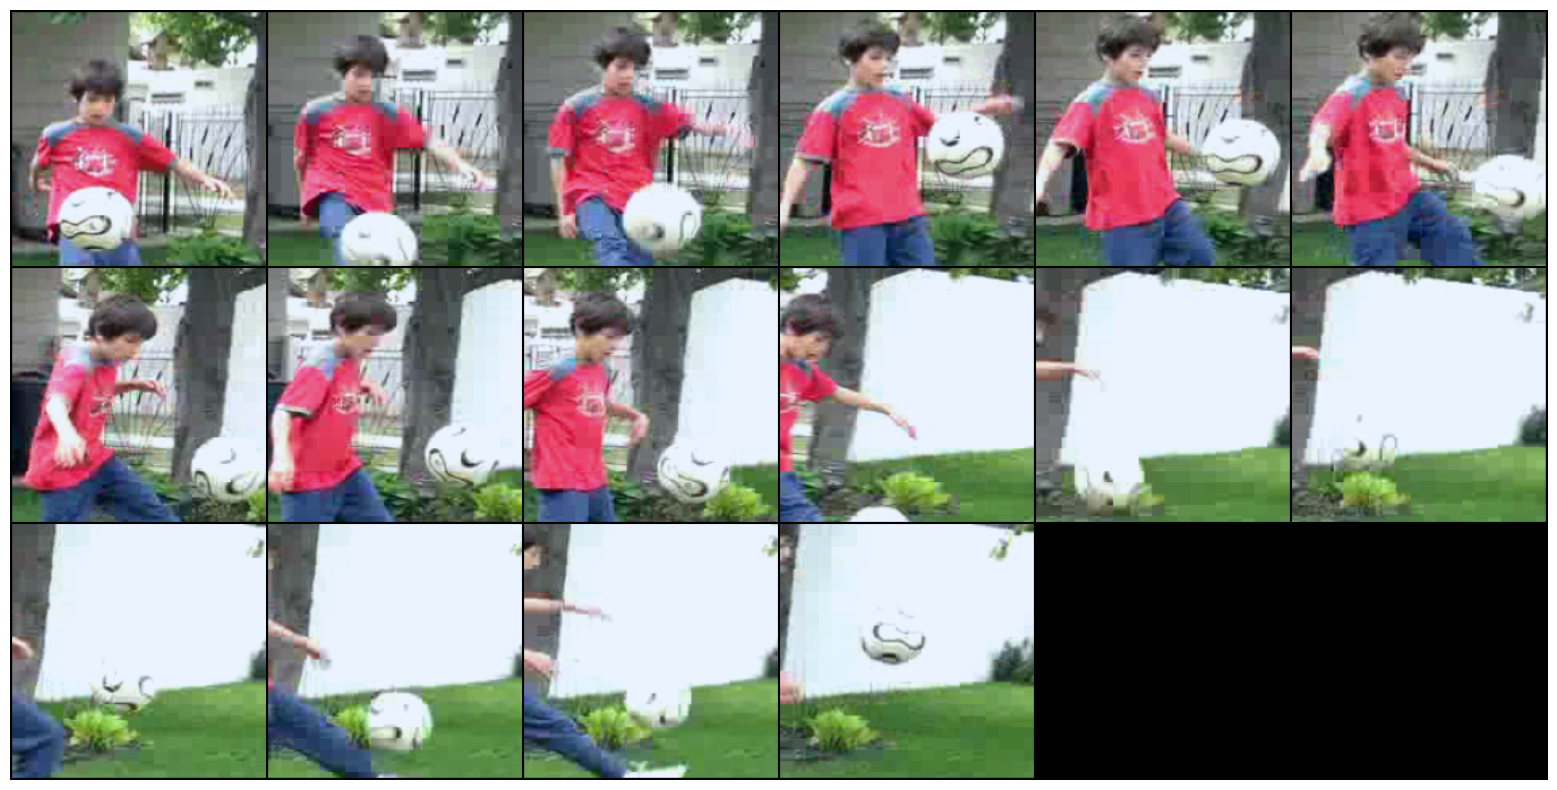

In [15]:
i=0
plt.figure(figsize=(20,10))
plt.imshow(make_grid(video_data[i].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

encoder_mask_.shape=torch.Size([16, 32, 14, 14]), encoder_mask.shape=torch.Size([64, 8, 196])


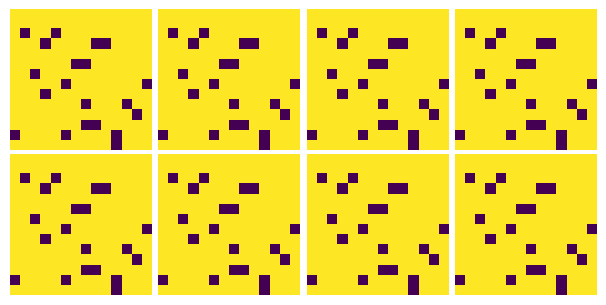

In [16]:
n_patches=int(np.sqrt(encoder_mask.shape[-1]))
encoder_mask_=encoder_mask.view(args.batch_size, -1, n_patches,n_patches)
print(f"{encoder_mask_.shape=}, {encoder_mask.shape=}")

i=4
fig, ax=plt.subplots(2,4,figsize=(6,3))
for j in range(2):
    for k in range(4):
        m=4*j+k
        ax[j,k].imshow(encoder_mask_[i,k])#, cmap='gray')
        ax[j,k].axis('off')
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

decoder_mask_.shape=torch.Size([16, 32, 14, 14]), decoder_mask.shape=torch.Size([64, 8, 196])


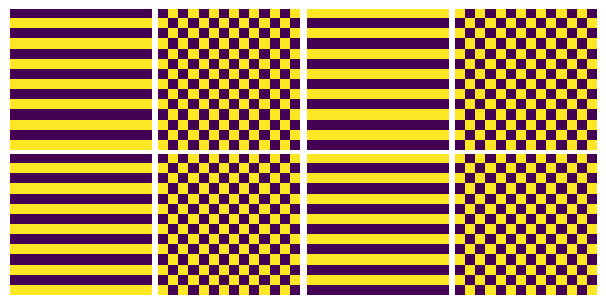

In [17]:
n_patches=int(np.sqrt(decoder_mask.shape[-1]))
decoder_mask_=decoder_mask.view(args.batch_size, -1, n_patches,n_patches)
print(f"{decoder_mask_.shape=}, {decoder_mask.shape=}")

i=2
fig, ax=plt.subplots(2,4,figsize=(6,3))
for j in range(2):
    for k in range(4):
        m=4*j+k
        ax[j,k].imshow(decoder_mask_[i,k])#, cmap='gray')
        ax[j,k].axis('off')
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)